In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/10011
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

152


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 13
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17068.886839794224
Gradient descend method:  None
RUN  0 , total integrated cost =  17068.886839794224
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  39 0.5250000000000001 0.5250000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  350.9300698344639
RUN  2 , total integrated cost =  169.24355196132038
RUN  3 , total integrated cost =  152.34446749232117
RUN  4 , total integrated cost =  148.76652290129692
RUN  5 , total integrated cost =  143.11014064411032
RUN  6 , total integrated cost =  140.20414477094178
RUN  7 , total integrated cost =  136.32955644597527
RUN  8 , total integrated cost =  132.2078349004598
RUN  9 , total integrated cost =  127.20747354170125
RUN  10 , total integrated cost =  122.5231994418676
RUN  11 , total integrated cost =  119.13189611773143
RUN  12 , total integrated cost =  112.63587536450947
RUN  13 , total integrated cost =  111.39023756962754
RUN  14 , total integrated cost =  110.8809689535823
RUN  15 , total integrated cost =  110.37904753263565
RU

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  511 , total integrated cost =  102.54407626269236
Improved over  511  iterations in  58.92031760327518  seconds by  98.26267342611206  percent.
Problem in initial value trasfer:  Vmean_exc -63.21502323247917 -63.209225218008676
weight =  575.5970207501689
set cost params:  1.0 0.0 575.5970207501689
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5895.925440882826
Gradient descend method:  None
RUN  1 , total integrated cost =  5882.4279311455975
RUN  2 , total integrated cost =  5882.419100593967
RUN  3 , total integrated cost =  5882.179709705041
RUN  4 , total integrated cost =  5881.9085723726075
RUN  5 , total integrated cost =  5881.899676568918
RUN  6 , total integrated cost =  5881.814199102528
RUN  7 , total integrated cost =  5881.693377044825
RUN  8 , total integrated cost =  5881.686170292699
RUN  9 , total integrated cost =  5880.2797438401885
RUN  10 , total integrated cost =  5879.071485744191
RUN  11 , total i

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  35 , total integrated cost =  5875.604366178881
Improved over  35  iterations in  2.6058761831372976  seconds by  0.34466302038076435  percent.
Problem in initial value trasfer:  Vmean_exc -64.40525689011164 -64.41798649650185
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  1 , total integrated cost =  13246.700445869352
RUN  2 , total integrated cost =  13209.820727872035
RUN  3 , total integrated cost =  13209.542643652494
RUN  4 , total integrated cost =  13209.539476689772
RUN  5 , total integrated cost =  13209.536007794624
RUN  6 , total integrated cost =  13209.533839701991
RUN  7 , total integrated cost =  13209.532235732222
RUN  8 , total integrated cost =  13209.528706834306
RUN  9 , total integrated cost =  13209.525826728794
RUN  10 , total integrated cost =  13209.525591945303

...

RUN  1 , total integrated cost =  13490.905140210181
Control only changes marginally.
RUN  1 , total integrated cost =  13490.905140210181
Improved over  1  iterations in  0.31581063754856586  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67145507052048 -56.6716100331032
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38613.011975189
Gradient descend method:  None
RUN  1 , total integrated cost =  37604.69892266846
RUN  2 , total integrated cost =  37486.7412727018
RUN  3 , total integrated cost =  37474.18546895146
RUN  4 , total integrated cost =  37473.84435410746
RUN  5 , total integrated cost =  37473.840721302455


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  37473.840721302455
Control only changes marginally.
RUN  6 , total integrated cost =  37473.840721302455
Improved over  6  iterations in  0.932867031544447  seconds by  2.950226350170581  percent.
Problem in initial value trasfer:  Vmean_exc -56.701168665326996 -56.70114838504753
weight =  10.30399105935223
set cost params:  1.0 0.0 10.30399105935223
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37477.05725611635
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  37477.05725611635
Control only changes marginally.
RUN  1 , total integrated cost =  37477.05725611635
Improved over  1  iterations in  0.3204082362353802  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.701168665326996 -56.70114838504753


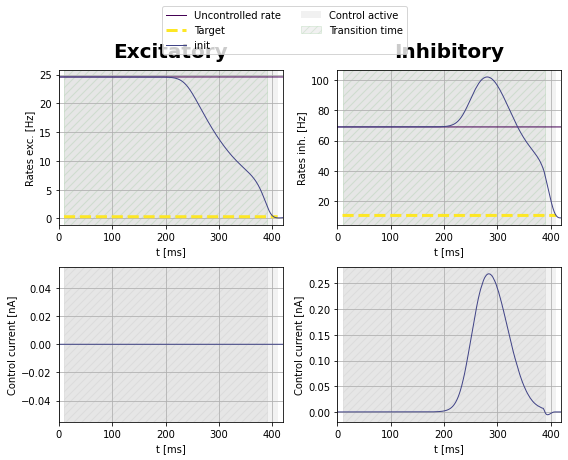

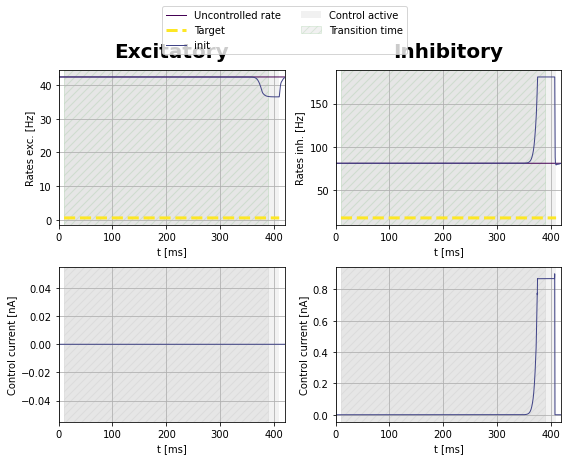

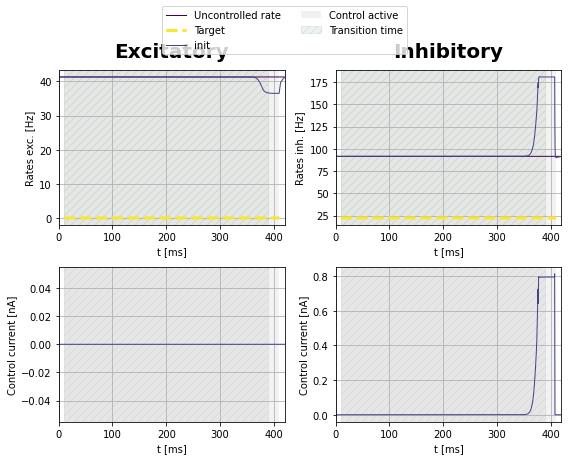

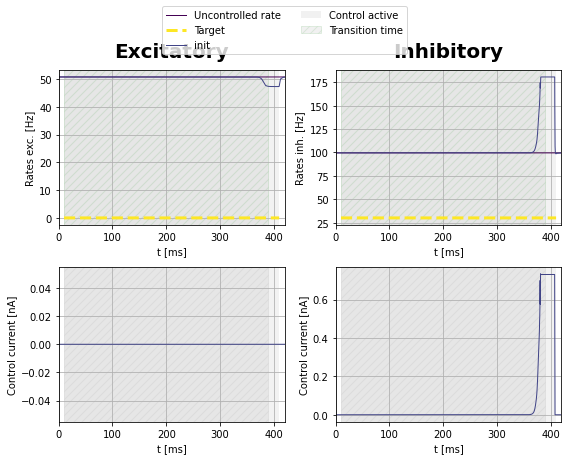

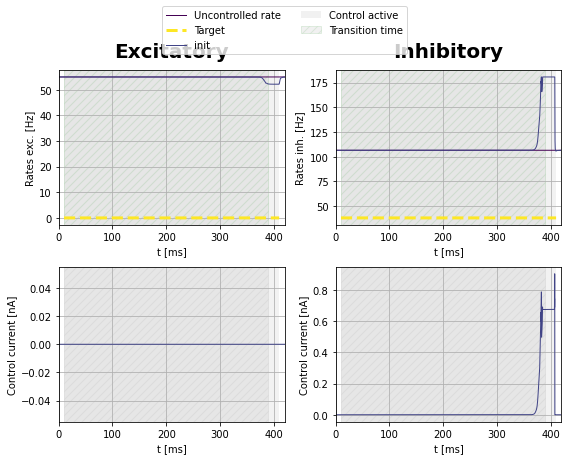

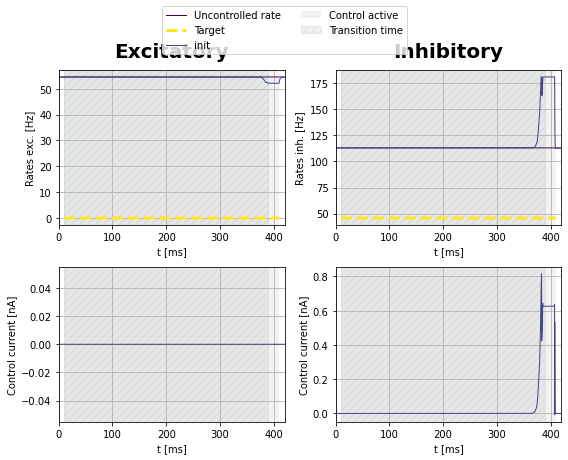

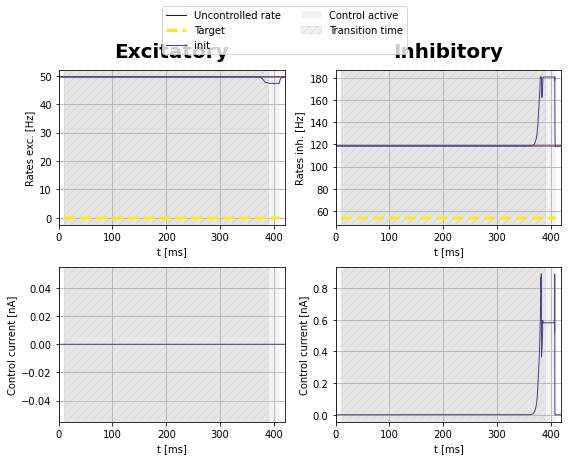

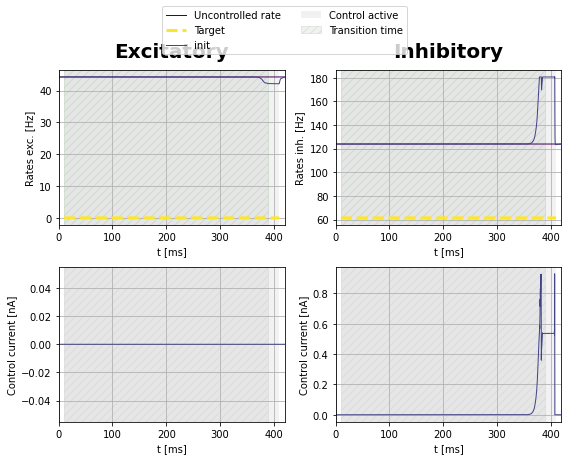

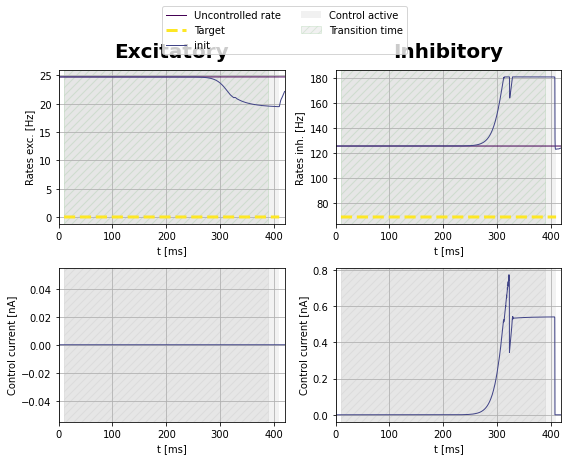

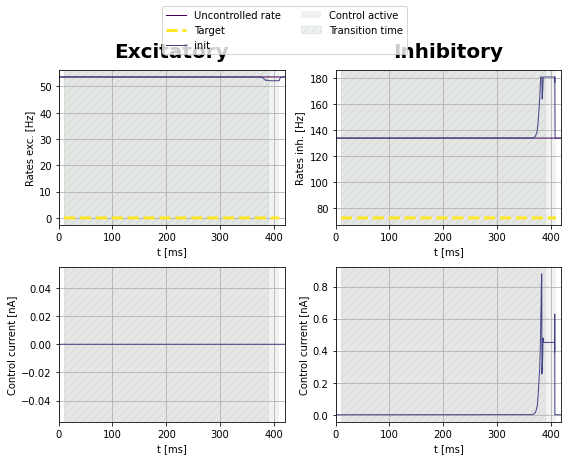

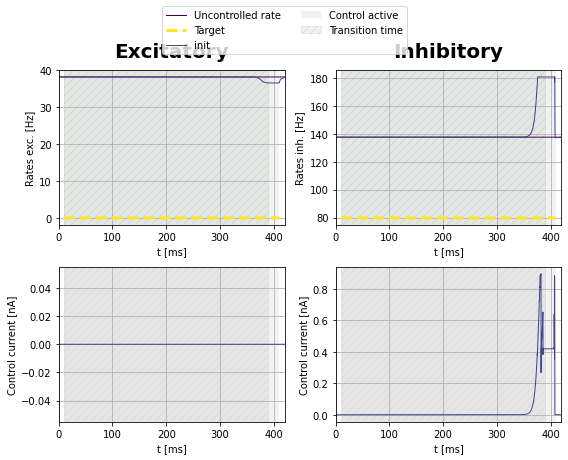

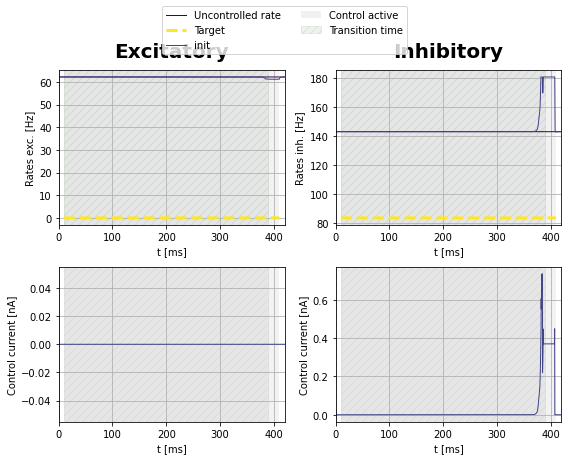

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 152
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  13 0.47500000000000014 0.40000000000000013
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
inter

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  48 , total integrated cost =  13210.62441373925
Improved over  48  iterations in  4.607491401955485  seconds by  25.258096209767515  percent.
Problem in initial value trasfer:  Vmean_exc -56.67181407725285 -56.67223525174743
weight =  13.285630772124524
set cost params:  1.0 0.0 13.285630772124524
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13291.963350312024
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  13291.963350312024
Control only changes marginally.
RUN  1 , total integrated cost =  13291.963350312024
Improved over  1  iterations in  0.18643518909811974  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67181407725285 -56.67223525174743
-------  26 0.47500000000000014 0.4750000000000002
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17187.21707733315
Gradient descend method:  None
RUN  1 , total integrated cost =  13627.125112812773
RUN  2 , total integrated cost =  13571.420122483878
RUN  3 , total integrated cost =  13570.443713434805
RUN  4 , total integrated cost =  13570.42819252108
RUN  5 , total integrated cost =  13570.424355921075
RUN  6 , total integrated cost =  13570.420831681566
RUN  7 , total integrated cost =  13570.420166075308
RUN  8 , total integrated cost =  13570.418678552422
RUN  9 , total integrated 

...

Control only changes marginally.
RUN  1 , total integrated cost =  13473.669967327336
Improved over  1  iterations in  0.18677549436688423  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67167623596397 -56.67184039056231
-------  143 0.6000000000000003 0.8750000000000006
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38725.26904359284
Gradient descend method:  None
RUN  1 , total integrated cost =  37610.26676502608
RUN  2 , total integrated cost =  37470.97252348896
RUN  3 , total integrated cost =  37468.09422750263
RUN  4 , total integrated cost =  37468.05330137458
RUN  5 , total integrated cost =  37468.053257368076
RUN  6 , total integrated cost =  37468.053256877574
RUN  7 , total integrated cost =  37468.05325685408
RUN  8 , total integrated cost =  37468.05325685353


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  37468.0532568535
RUN  10 , total integrated cost =  37468.0532568535
Control only changes marginally.
RUN  10 , total integrated cost =  37468.0532568535
Improved over  10  iterations in  0.8252591080963612  seconds by  3.2464998121100166  percent.
Problem in initial value trasfer:  Vmean_exc -56.70116868509332 -56.701149475615914
weight =  10.305582654771655
set cost params:  1.0 0.0 10.305582654771655
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37470.96476301942
Gradient descend method:  None
RUN  1 , total integrated cost =  37470.96476296231
RUN  2 , total integrated cost =  37470.9647629623


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  37470.9647629623
Control only changes marginally.
RUN  3 , total integrated cost =  37470.9647629623
Improved over  3  iterations in  0.5078677143901587  seconds by  1.524398385299719e-10  percent.
Problem in initial value trasfer:  Vmean_exc -56.70116868509262 -56.70114947561684
------------------------------------------------------------
-------------------- 1
------------------------------------------------------------
found solution:  [0]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
closest index  -1
set cost params:  1.0 0.0 10.0
all options tried already
-------  26 0.47500000000000014 0.4750000000000002
closest index  -1
set cost params:  1.0 0.0 10.0
all options tried already
-------  39 0.5250000000000001 0.5250000000000002
closest index  -1
set cost params:  1.0 0.0 10.0
all options tried already
-------  52 0.5500000000000003 0.5750000000000003
closest index  -1
set cos

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  577.222659827514
set cost params:  1.0 0.0 577.222659827514
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5892.183326109504
Gradient descend method:  None
RUN  1 , total integrated cost =  5892.183314724976
RUN  2 , total integrated cost =  5892.183314122733
RUN  3 , total integrated cost =  5892.1833140267445
RUN  4 , total integrated cost =  5892.183314011596
RUN  5 , total integrated cost =  5892.1833140084755
RUN  6 , total integrated cost =  5892.183314007665
RUN  7 , total integrated cost =  5892.183314007466
RUN  8 , total integrated cost =  5892.183314007409
RUN  9 , total integrated cost =  5892.183314007377
RUN  10 , total integrated cost =  5892.183314007375


ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  5892.183314007375
Control only changes marginally.
RUN  11 , total integrated cost =  5892.183314007375
Improved over  11  iterations in  1.5549311023205519  seconds by  2.0539296485821978e-07  percent.
Problem in initial value trasfer:  Vmean_exc -64.40359332921247 -64.41637688080378
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
no convergence
weight =  10.051828781425584
set cost params:  1.0 0.0 10.051828

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  27312.403146220815
Control only changes marginally.
RUN  1 , total integrated cost =  27312.403146220815
Improved over  1  iterations in  0.32078555785119534  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.703509401740995 -56.70354722151973
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  143 0.6000000000000003 0.8750000000000006
no convergence
weight =  9.619678168877211
set cost params:  1.0 0.0 9.619678168877211
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37464.42965720471
Gradient descend method:  None


...

RUN  1 , total integrated cost =  37464.42965720471
Control only changes marginally.
RUN  1 , total integrated cost =  37464.42965720471
Improved over  1  iterations in  0.322966281324625  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70116868509262 -56.70114947561684
[[False, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, False], [False, False], [True, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  577.2241633979257
set cost params:  1.0 0.0 577.2241633979257
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5892.198647995689
Gradient descend method:  None
RUN  1 , total integrated cost =  5892.1986479956495
RUN  2 , total integrated cost =  5892.198647995622
RUN  3 , total integrated cost =  5892.198647995616
RUN  4 , total integrated cost =  5892.198647995615
RUN  5 , total integrated cost =  5892.198647995614


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  5892.1986479956095
Control only changes marginally.
RUN  8 , total integrated cost =  5892.1986479956095
Improved over  8  iterations in  1.3695653304457664  seconds by  1.3500311979441904e-12  percent.
Problem in initial value trasfer:  Vmean_exc -64.40358815387454 -64.41637187299277
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
converged

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5892.198662190516
Control only changes marginally.
RUN  1 , total integrated cost =  5892.198662190516
Improved over  1  iterations in  0.3207437973469496  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -64.40358815387454 -64.41637187299277
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  14

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  107.42893378852031
Gradient descend method:  None
RUN  1 , total integrated cost =  102.28338727500014
RUN  2 , total integrated cost =  100.36804678942931
RUN  3 , total integrated cost =  100.33258365443334
RUN  4 , total integrated cost =  98.35468822886314
RUN  5 , total integrated cost =  98.20097007572951
RUN  6 , total integrated cost =  96.47376406311324
RUN  7 , total integrated cost =  96.418307341319
RUN  8 , total integrated cost =  96.36825465319149
RUN  9 , total integrated cost =  94.64647728254418
RUN  10 , total integrated cost =  94.59664874306189
RUN  11 , total integrated cost =  94.53854249163923
RUN  12 , total integrated cost =  92.82698646383149
RUN  13 , total integrated cost =  92.73502942588942
RUN  14 , total integrated cost =  90.79151882344881
RUN  15 , total integrated cost =  90.59185708580263
RUN  16 , t

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  78 , total integrated cost =  8.59196621363636
Improved over  78  iterations in  20.490914832800627  seconds by  92.00218608652477  percent.
Problem in initial value trasfer:  Vmean_exc -62.79042675121323 -62.790027261514155
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  85.72384172790807
Gradient descend method:  HS
RUN  1 , total integrated cost =  85.48803009933242
RUN  2 , total integrated cost =  85.44880064454837
RUN  3 , total integrated cost =  85.42292689334374
RUN  4 , total integrated cost =  85.4225893883224
RUN  5 , total integrated cost =  85.42253016905524
RUN  6 , total integrated cost =  85.42253016905514
RUN  7 , total integrated cost =  85.42253016905507
RUN  8 , total integrated cost =  85.42253016905505


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  85.42253016905505
Control only changes marginally.
RUN  9 , total integrated cost =  85.42253016905505
Improved over  9  iterations in  3.293212627992034  seconds by  0.35149096538322055  percent.
Problem in initial value trasfer:  Vmean_exc -64.34954012819533 -64.33896134858396
weight =  6908.660095009191
set cost params:  1.0 0.0 6908.660095009191
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5881.37742140407
Gradient descend method:  None
RUN  1 , total integrated cost =  5879.3943788263505
RUN  2 , total integrated cost =  5879.394114228274
RUN  3 , total integrated cost =  5879.394113739134
RUN  4 , total integrated cost =  5879.394113739083


...

Control only changes marginally.
RUN  317 , total integrated cost =  59.63853574204107
Improved over  317  iterations in  106.52564853429794  seconds by  99.8408283042279  percent.
Problem in initial value trasfer:  Vmean_exc -63.60379007873378 -63.61026648540223
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  590.0962120544614
Gradient descend method:  HS
RUN  1 , total integrated cost =  582.489525208125
RUN  2 , total integrated cost =  582.1366519816823
RUN  3 , total integrated cost =  582.1339258898699
RUN  4 , total integrated cost =  582.1109487475145
RUN  5 , total integrated cost =  582.1109487475143
RUN  6 , total integrated cost =  582.1109487475142


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  582.1109487475142
Control only changes marginally.
RUN  7 , total integrated cost =  582.1109487475142
Improved over  7  iterations in  2.925210691988468  seconds by  1.353213788501705  percent.
Problem in initial value trasfer:  Vmean_exc -61.37851943012189 -61.37975378633102
weight =  6632.273615325363
set cost params:  1.0 0.0 6632.273615325363
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38266.82744000568
Gradient descend method:  None
RUN  1 , total integrated cost =  37632.7027388588
RUN  2 , total integrated cost =  37631.590581461205
RUN  3 , total integrated cost =  37629.44001585776
RUN  4 , total integrated cost =  37627.50664880892
RUN  5 , total integrated cost =  37626.01890626212
RUN  6 , total integrated cost =  37624.63286121874
RUN  7 , total integrated cost =  37618.47905350679
RUN  8 , total integrated cost =  37615.74262430885
RUN  9 , total integrated cost =  37615.70060167355
RUN  10 , total integrated 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  527 , total integrated cost =  34096.77433159605
Improved over  527  iterations in  278.7054522987455  seconds by  10.897305544723821  percent.
Problem in initial value trasfer:  Vmean_exc -56.6961535368314 -56.698078608115516


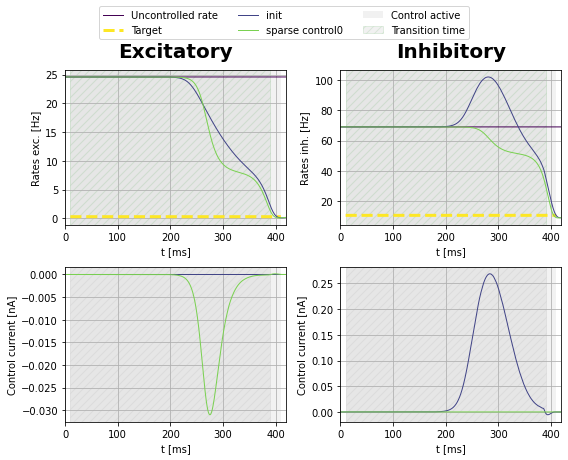

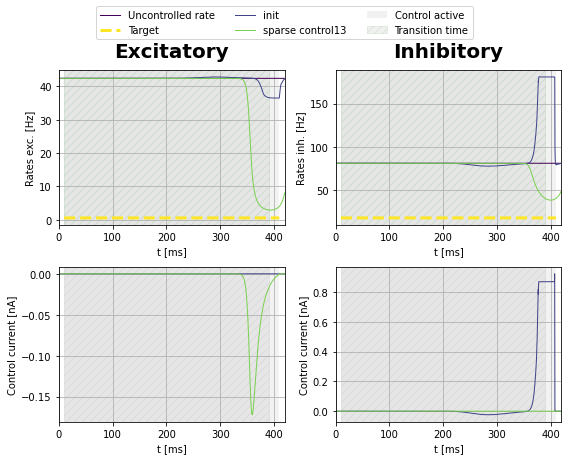

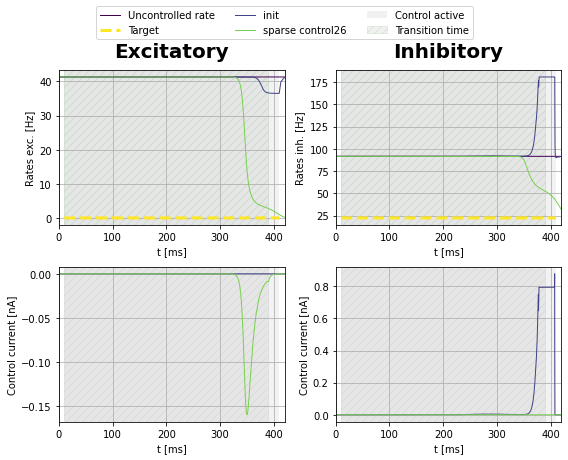

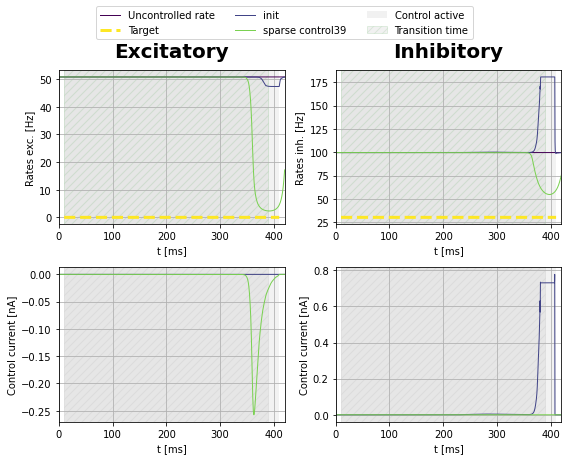

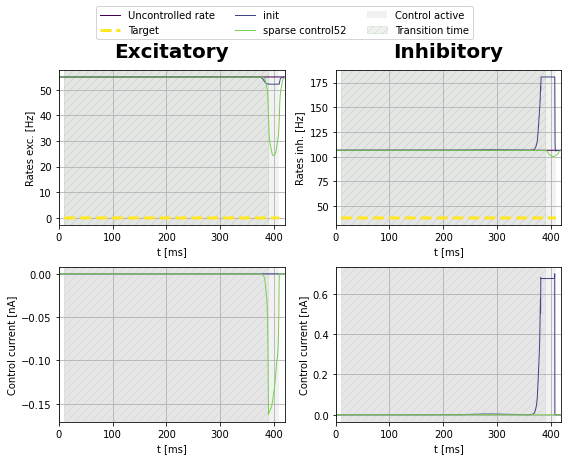

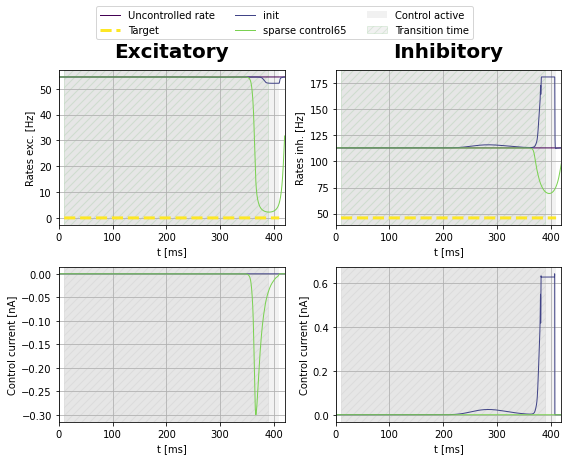

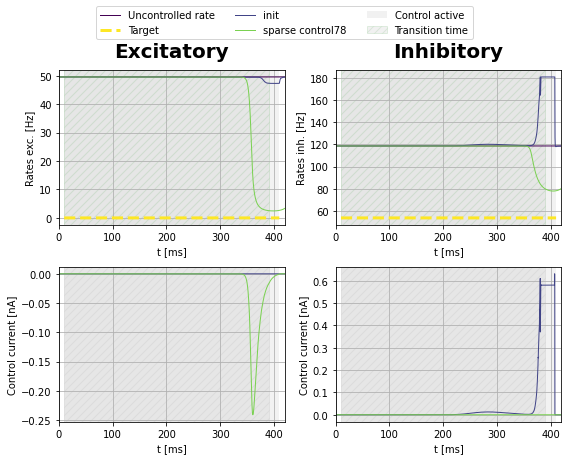

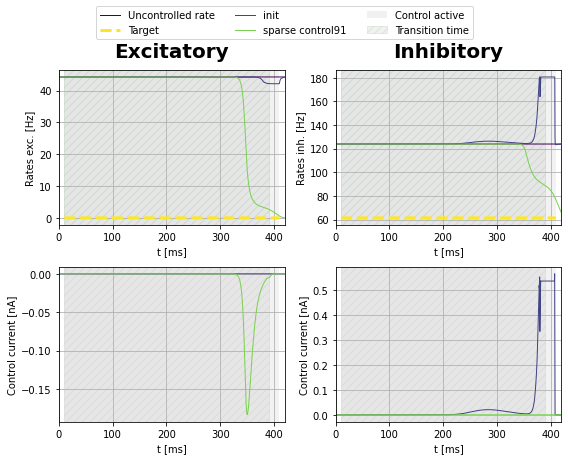

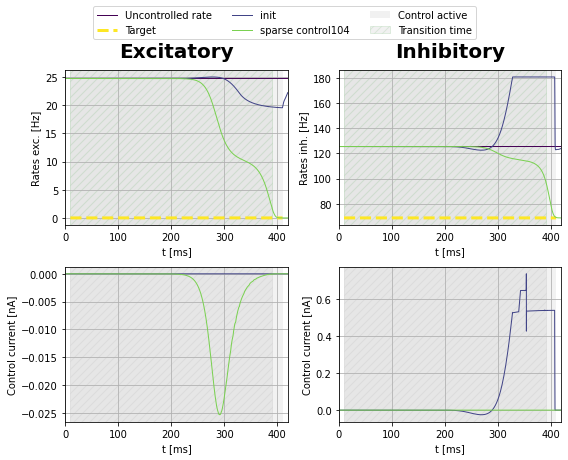

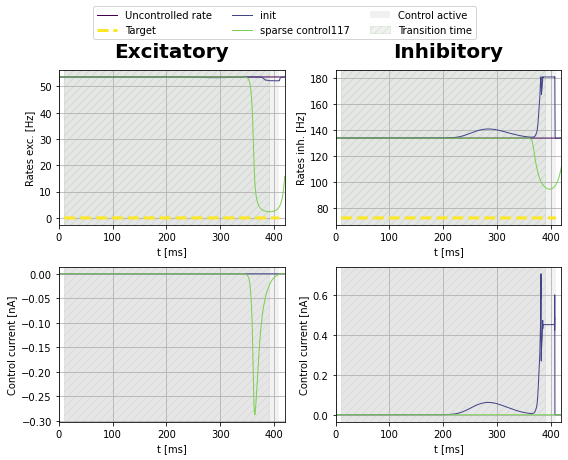

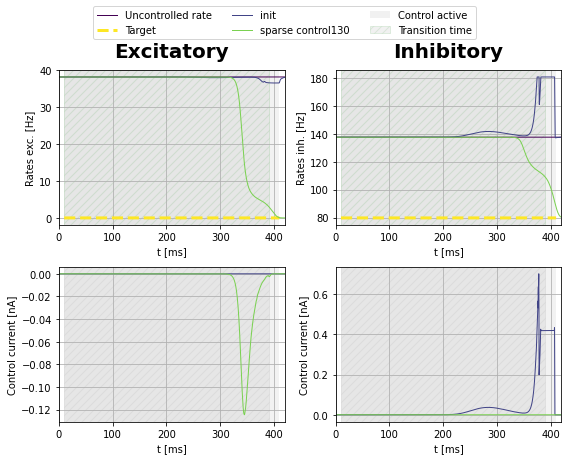

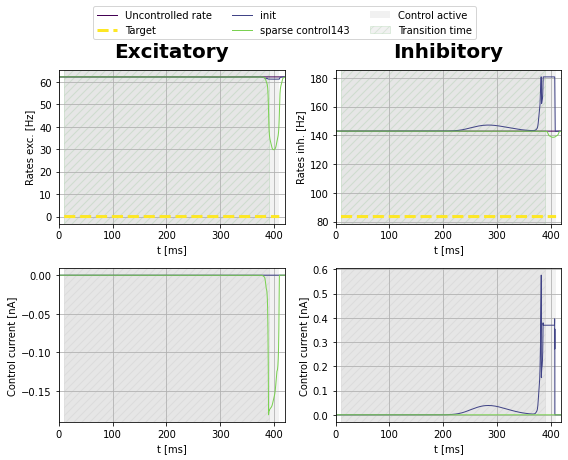

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6934.701080549736
set cost params:  1.0 0.0 6934.701080549736
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.5511421855
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.551137693159
RUN  2 , total integrated cost =  5901.551137691148
RUN  3 , total integrated cost =  5901.5511376911445
RUN  4 , total integrated cost =  5901.551137691143
RUN  5 , total integrated cost =  5901.551137691142
RUN  6 , total integrated cost =  5901.551137691141
RUN  7 , total integrated cost =  5901.55113769114


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  5901.55113769114
Control only changes marginally.
RUN  8 , total integrated cost =  5901.55113769114
Improved over  8  iterations in  5.833597857505083  seconds by  7.615557251483551e-08  percent.
Problem in initial value trasfer:  Vmean_exc -64.73756849129613 -64.73526612020515
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  5590.54796284647
set cost params:  1.0 0.0 5590.54796284647
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17546.710384021855
Gradient descend method:  None
RUN  1 , total integrated cost =  17546.703055316957
RUN  2 , total integrated cost =  17546.70304269437
RUN  3 , total integrated cost =  17546.70304161108
RUN  4 , total integrated cost =  17546.703041269193
RUN  5 , total integrated cost =  17546.703041244054
RUN  6 , total integrated cost =  17546.70304124373


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  17546.70304124373
Control only changes marginally.
RUN  7 , total integrated cost =  17546.70304124373
Improved over  7  iterations in  5.17141873575747  seconds by  4.1847035504360974e-05  percent.
Problem in initial value trasfer:  Vmean_exc -58.16683097782032 -58.15941616384488
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  5851.262566337275
set cost params:  1.0 0.0 5851.262566337275
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17065.4448409035
Gradient descend method:  None
RUN  1 , total integrated cost =  17065.443871903244
RUN  2 , total integrated cost =  17065.443802854348
RUN  3 , total integrated cost =  17065.44378687646
RUN  4 , total integrated cost =  17065.44378471591
RUN  5 , total integrated cost =  17065.443784715902
RUN  6 , total integrated cost =  17065.4437847159


...

RUN  7 , total integrated cost =  30186.804405237806
Control only changes marginally.
RUN  7 , total integrated cost =  30186.804405237806
Improved over  7  iterations in  3.0336283706128597  seconds by  9.464783090606943e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.70438258464887 -56.70438539114455
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
--------------- 99
[[True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
------

ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  30186.833220226505
Control only changes marginally.
RUN  3 , total integrated cost =  30186.833220226505
Improved over  3  iterations in  1.532536355778575  seconds by  8.715896626654285e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.70438262569985 -56.70438542700751
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
--------------- 100
[[True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
------

ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  30186.86099951883
Control only changes marginally.
RUN  4 , total integrated cost =  30186.86099951883
Improved over  4  iterations in  1.9733947832137346  seconds by  1.354144103515864e-07  percent.
Problem in initial value trasfer:  Vmean_exc -56.704382685037764 -56.704385478846696
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
--------------- 101


In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.9994881671948528
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9218985190806833
RUN  2 , total integrated cost =  0.9200313619120977
RUN  3 , total integrated cost =  0.9191338596517998
RUN  4 , total integrated cost =  0.9188322318381374
RUN  5 , total integrated cost =  0.918490584646111
RUN  6 , total integrated cost =  0.9184627655994082
RUN  7 , total integrated cost =  0.9184627552387883
RUN  8 , total integrated cost =  0.9184627546169871
RUN  9 , total integrated cost =  0.9184627546169817
RUN  10 , total integrated cost =  0.9184627546169811


ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  0.9184627546169811
Control only changes marginally.
RUN  11 , total integrated cost =  0.9184627546169811
Improved over  11  iterations in  1.631909016519785  seconds by  54.065106776524594  percent.
Problem in initial value trasfer:  Vmean_exc -62.799432508764866 -62.79945533687362
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  73.71538624663239
Gradient descend method:  None
RUN  1 , total integrated cost =  4.474483458666755
RUN  2 , total integrated cost =  4.373726940174212
RUN  3 , total integrated cost =  4.3078191879816385
RUN  4 , total integrated cost =  4.264739832393634
RUN  5 , total integrated cost =  4.234709522213539
RUN  6 , total integrated cost =  4.221207941787848
RUN  7 , total integrated cost =  4.209932253185303
RUN  8 , total integrated cost =  4.207752598514835
RUN  9 , total integrated cost =  4.207102777804788
RUN  10 ,

ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  4.205997890929185
Control only changes marginally.
RUN  19 , total integrated cost =  4.205997890929185
Improved over  19  iterations in  2.817530205473304  seconds by  94.29427409244386  percent.
Problem in initial value trasfer:  Vmean_exc -61.81290459783351 -61.811825385528486
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  42.83588785549254
Gradient descend method:  None
RUN  1 , total integrated cost =  3.8690539324087427
RUN  2 , total integrated cost =  3.8643511967361053
RUN  3 , total integrated cost =  3.8637145121757737
RUN  4 , total integrated cost =  3.8636695895970643
RUN  5 , total integrated cost =  3.8635500577779944
RUN  6 , total integrated cost =  3.8632765693265654
RUN  7 , total integrated cost =  3.8632765693265636
RUN  8 , total integrated cost =  3.863276569326562
RUN  9 , total integrated cost =  3.863276569326561
RUN  10

...

RUN  5 , total integrated cost =  9.680238655486473
Control only changes marginally.
RUN  5 , total integrated cost =  9.680238655486473
Improved over  5  iterations in  1.0461225137114525  seconds by  88.87829155278986  percent.
Problem in initial value trasfer:  Vmean_exc -65.11965332657643 -65.14205367224938
-------  130 0.47500000000000014 0.8500000000000005
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30.202295981436748
Gradient descend method:  None
RUN  1 , total integrated cost =  3.6175429895626134
RUN  2 , total integrated cost =  3.616718175077846
RUN  3 , total integrated cost =  3.6167067217329643
RUN  4 , total integrated cost =  3.6167067217329616
RUN  5 , total integrated cost =  3.6167067217329607


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  3.6167067217329607
Control only changes marginally.
RUN  6 , total integrated cost =  3.6167067217329607
Improved over  6  iterations in  1.1269060391932726  seconds by  88.02506033330745  percent.
Problem in initial value trasfer:  Vmean_exc -70.86010409691553 -70.89554949017888
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37154.50648851757
Gradient descend method:  None
RUN  1 , total integrated cost =  35945.393825235864
RUN  2 , total integrated cost =  35931.08187236277
RUN  3 , total integrated cost =  35930.40210983498
RUN  4 , total integrated cost =  35930.389539671494
RUN  5 , total integrated cost =  35930.38906930868


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  35930.38906930868
Control only changes marginally.
RUN  6 , total integrated cost =  35930.38906930868
Improved over  6  iterations in  1.0230783727020025  seconds by  3.2946674169584043  percent.
Problem in initial value trasfer:  Vmean_exc -56.70178710884928 -56.70171748742812


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.9184627546169811
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9184627322291431
RUN  2 , total integrated cost =  0.9184627322291347
RUN  3 , total integrated cost =  0.9184627322291341
RUN  4 , total integrated cost =  0.918462732229134


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  0.918462732229134
Control only changes marginally.
RUN  5 , total integrated cost =  0.918462732229134
Improved over  5  iterations in  1.030179115012288  seconds by  2.437534561749999e-06  percent.
Problem in initial value trasfer:  Vmean_exc -62.799536284326315 -62.79955213695094
-------  13 0.47500000000000014 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4.205997890929185
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  4.205997890929185
Control only changes marginally.
RUN  1 , total integrated cost =  4.205997890929185
Improved over  1  iterations in  0.30959561839699745  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -61.81290459783351 -61.811825385528486
-------  26 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.8632765693265596
Gradient descend method:  None


...

RUN  1 , total integrated cost =  3.6167067217329607
Control only changes marginally.
RUN  1 , total integrated cost =  3.6167067217329607
Improved over  1  iterations in  0.3062872104346752  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -70.86010409691553 -70.89554949017888
-------  143 0.6000000000000003 0.8750000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  35930.38906930868
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  35930.38906930868
Control only changes marginally.
RUN  1 , total integrated cost =  35930.38906930868
Improved over  1  iterations in  0.32708275131881237  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70178710884928 -56.70171748742812
--------------- 12
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.918462732229134
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.918462732229134
Control only changes marginally.
RUN  1 , total integrated cost =  0.918462732229134
Improved over  1  iterations in  0.30403107963502407  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -62.799536284326315 -62.79955213695094
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
